In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import ast

# Plot settings
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style="whitegrid")

# Load processed data
df = pd.read_csv("/Users/ashishjain/Documents/assignment/transcript-intelligence/data/processed/all_calls.csv")

# Fix list columns (they become strings in CSV)
df["topics"]       = df["topics"].apply(ast.literal_eval)
df["action_items"] = df["action_items"].apply(ast.literal_eval)
df["speakers"]     = df["speakers"].apply(ast.literal_eval)
df["participants"] = df["participants"].apply(ast.literal_eval)

print(f"✅ Loaded {len(df)} calls")
print(f"📋 Columns: {df.columns.tolist()}")

Matplotlib is building the font cache; this may take a moment.


✅ Loaded 100 calls
📋 Columns: ['meeting_id', 'title', 'duration_mins', 'start_time', 'participants', 'num_participants', 'summary', 'topics', 'sentiment', 'sentiment_score', 'action_items', 'num_action_items', 'key_moments', 'full_text', 'num_sentences', 'positive_sents', 'negative_sents', 'neutral_sents', 'speakers', 'num_speakers', 'call_type']


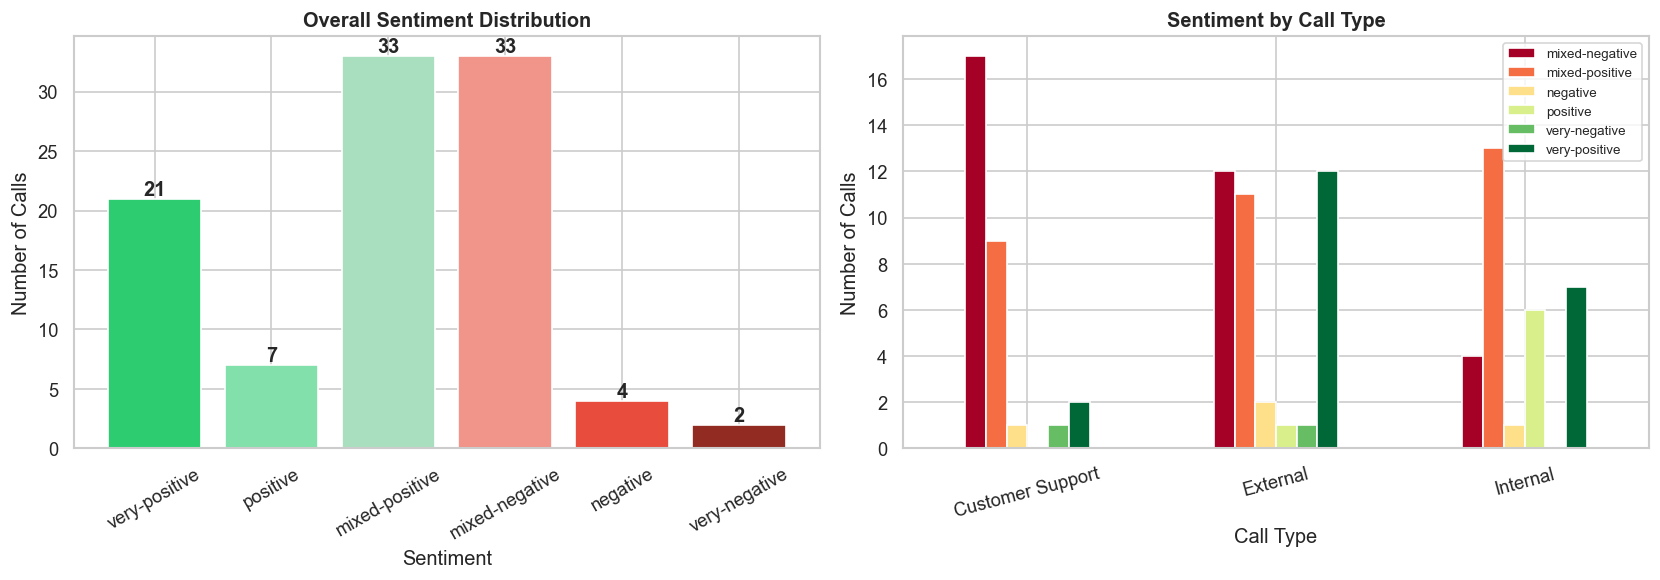

✅ Chart saved


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall sentiment
sentiment_order = ["very-positive", "positive", "mixed-positive",
                   "mixed-negative", "negative", "very-negative"]
colors = ["#2ecc71", "#82e0aa", "#a9dfbf",
          "#f1948a", "#e74c3c", "#922b21"]

sentiment_counts = df["sentiment"].value_counts().reindex(sentiment_order).fillna(0)

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors)
axes[0].set_title("Overall Sentiment Distribution", fontweight="bold")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Number of Calls")
axes[0].tick_params(axis="x", rotation=30)

for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 0.3, str(int(v)), ha="center", fontweight="bold")

# Sentiment by call type
sentiment_by_type = df.groupby(["call_type", "sentiment"]).size().unstack(fill_value=0)
sentiment_by_type.plot(kind="bar", ax=axes[1], colormap="RdYlGn")
axes[1].set_title("Sentiment by Call Type", fontweight="bold")
axes[1].set_xlabel("Call Type")
axes[1].set_ylabel("Number of Calls")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("/Users/ashishjain/Documents/assignment/transcript-intelligence/outputs/charts/sentiment_distribution.png",
            bbox_inches="tight")
plt.show()
print("✅ Chart saved")

/var/folders/dr/mh095vrx47v864kyvzp102g00000gn/T/ipykernel_9362/1188532734.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="call_type", y="sentiment_score",


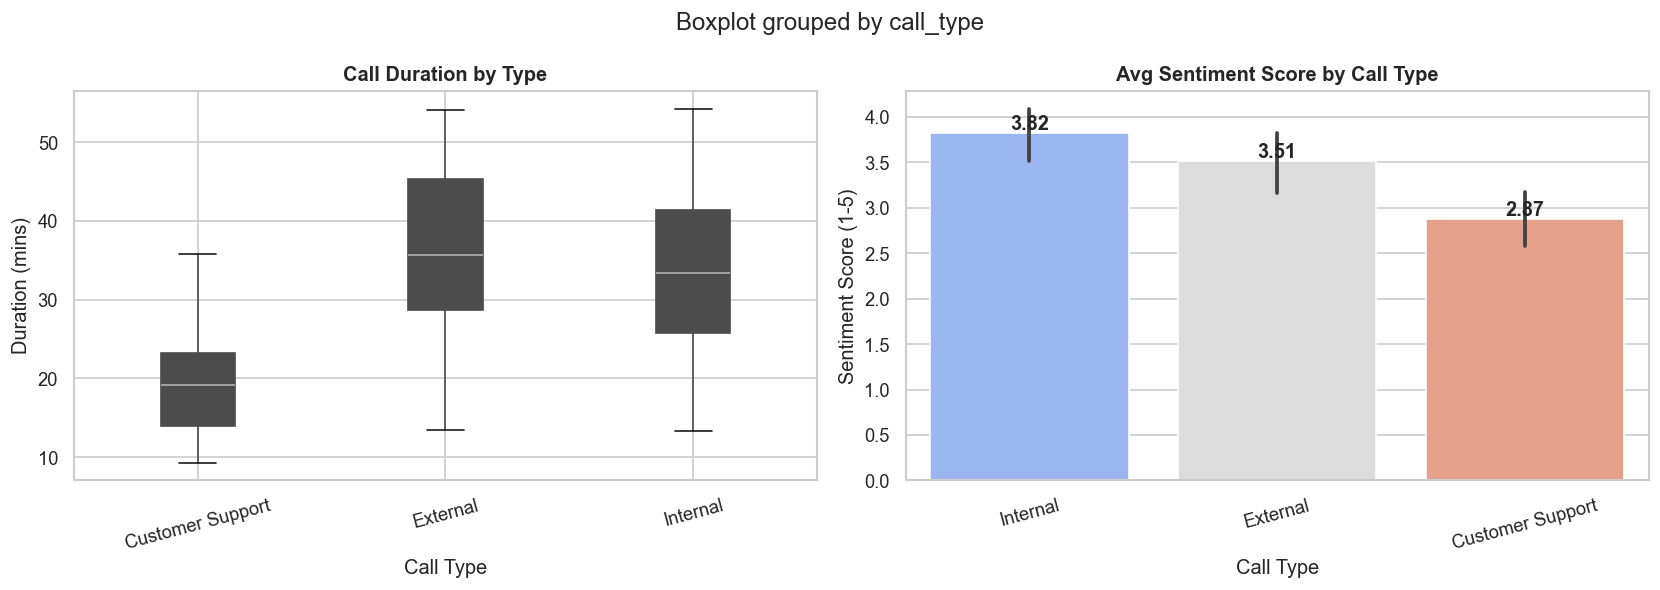

✅ Chart saved


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot duration by call type
colors_box = ["#3498db", "#e74c3c", "#2ecc71"]
df.boxplot(column="duration_mins", by="call_type",
           ax=axes[0], patch_artist=True)
axes[0].set_title("Call Duration by Type", fontweight="bold")
axes[0].set_xlabel("Call Type")
axes[0].set_ylabel("Duration (mins)")
plt.sca(axes[0])
plt.xticks(rotation=15)

# Sentiment score by call type
sns.barplot(data=df, x="call_type", y="sentiment_score",
            palette="coolwarm", ax=axes[1])
axes[1].set_title("Avg Sentiment Score by Call Type", fontweight="bold")
axes[1].set_xlabel("Call Type")
axes[1].set_ylabel("Sentiment Score (1-5)")
axes[1].tick_params(axis="x", rotation=15)

# Add value labels
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig("/Users/ashishjain/Documents/assignment/transcript-intelligence/outputs/charts/duration_analysis.png",
            bbox_inches="tight")
plt.show()
print("✅ Chart saved")

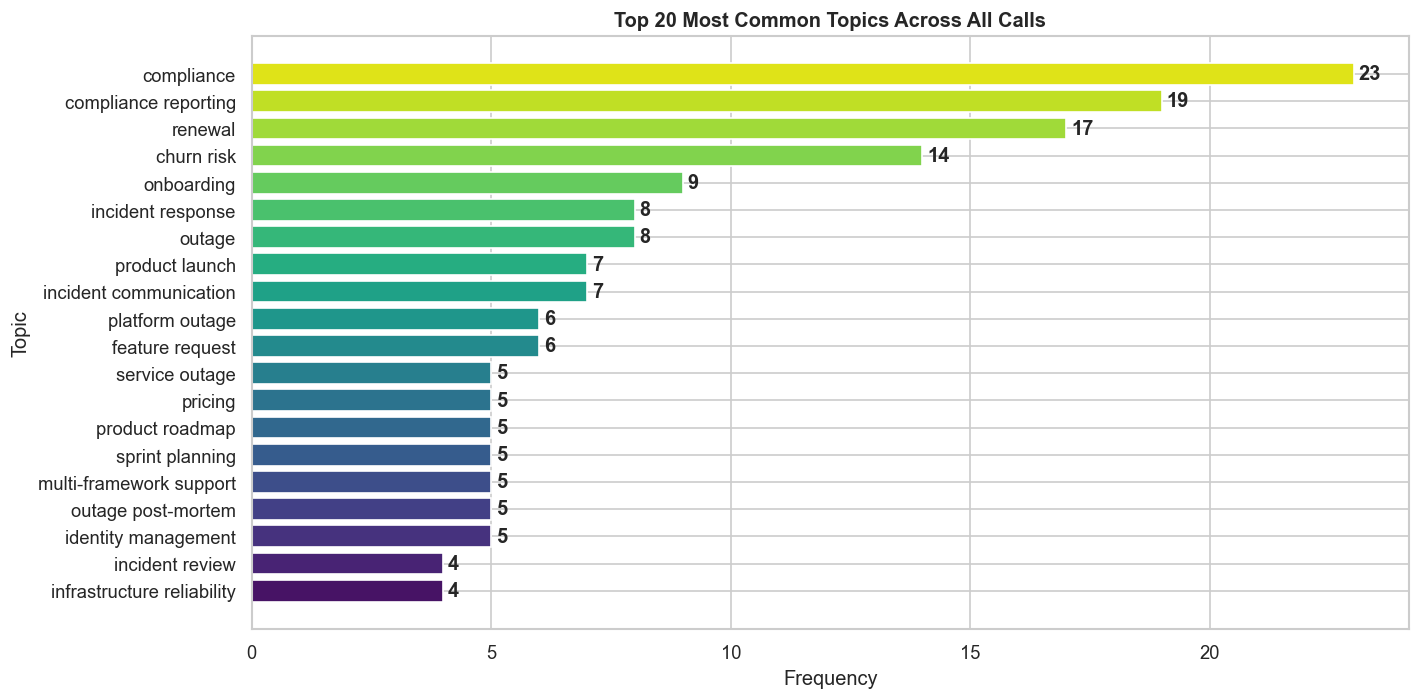

✅ Total unique topics: 351
✅ Total topic mentions: 600


In [4]:
from collections import Counter

# Flatten all topics
all_topics = [topic for topics in df["topics"] for topic in topics]
topic_counts = Counter(all_topics).most_common(20)

topics_df = pd.DataFrame(topic_counts, columns=["topic", "count"])

plt.figure(figsize=(12, 6))
bars = plt.barh(topics_df["topic"][::-1],
                topics_df["count"][::-1],
                color=sns.color_palette("viridis", len(topics_df)))
plt.title("Top 20 Most Common Topics Across All Calls", fontweight="bold")
plt.xlabel("Frequency")
plt.ylabel("Topic")

for bar, count in zip(bars, topics_df["count"][::-1]):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             str(count), va="center", fontweight="bold")

plt.tight_layout()
plt.savefig("/Users/ashishjain/Documents/assignment/transcript-intelligence/outputs/charts/top_topics.png",
            bbox_inches="tight")
plt.show()
print(f"✅ Total unique topics: {len(set(all_topics))}")
print(f"✅ Total topic mentions: {len(all_topics)}")

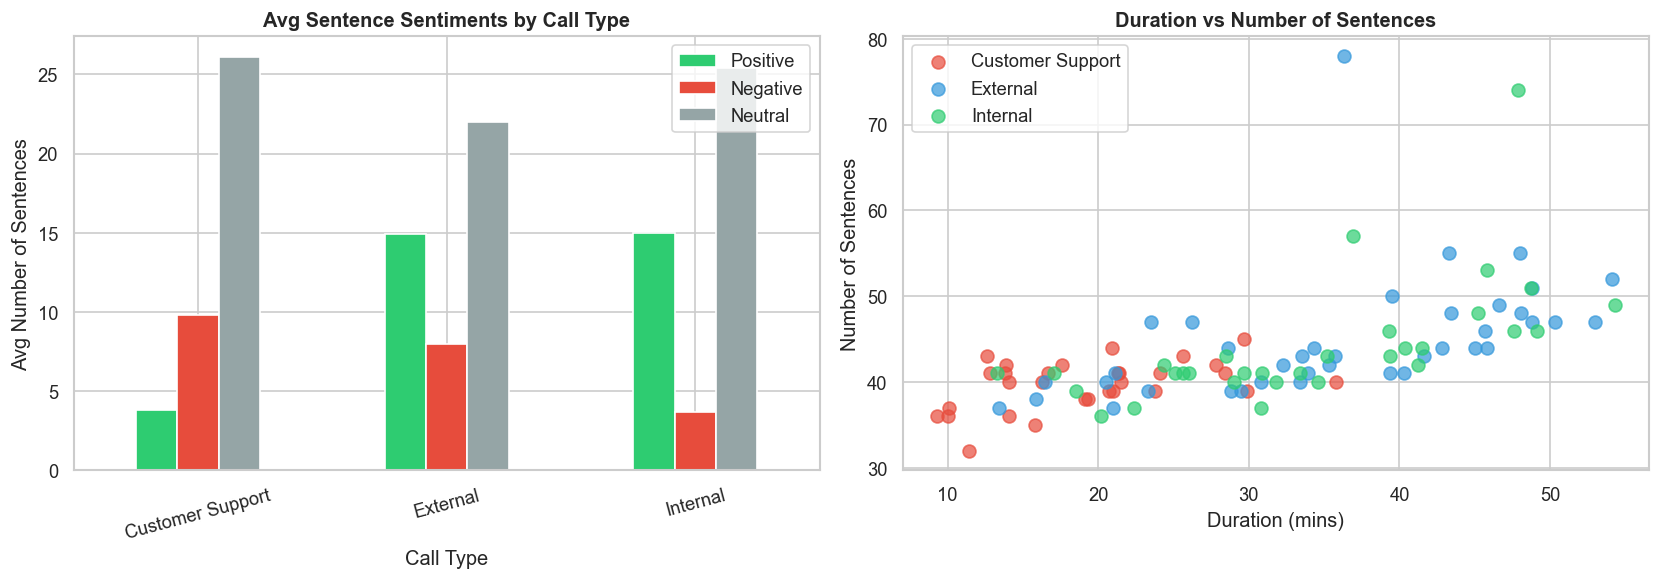

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avg sentence sentiments by call type
sent_by_type = df.groupby("call_type")[
    ["positive_sents", "negative_sents", "neutral_sents"]
].mean().round(1)

sent_by_type.plot(kind="bar", ax=axes[0],
                  color=["#2ecc71", "#e74c3c", "#95a5a6"])
axes[0].set_title("Avg Sentence Sentiments by Call Type", fontweight="bold")
axes[0].set_xlabel("Call Type")
axes[0].set_ylabel("Avg Number of Sentences")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(["Positive", "Negative", "Neutral"])

# Sentences vs duration scatter
scatter_colors = {"Customer Support": "#e74c3c",
                  "External": "#3498db",
                  "Internal": "#2ecc71"}

for ctype, group in df.groupby("call_type"):
    axes[1].scatter(group["duration_mins"], group["num_sentences"],
                    label=ctype, color=scatter_colors[ctype],
                    alpha=0.7, s=60)

axes[1].set_title("Duration vs Number of Sentences", fontweight="bold")
axes[1].set_xlabel("Duration (mins)")
axes[1].set_ylabel("Number of Sentences")
axes[1].legend()

plt.tight_layout()
plt.savefig("/Users/ashishjain/Documents/assignment/transcript-intelligence/outputs/charts/sentence_analysis.png",
            bbox_inches="tight")
plt.show()

In [6]:
print("=" * 55)
print("📊 DATASET EXPLORATION SUMMARY")
print("=" * 55)

print(f"\n📞 Total Calls         : {len(df)}")
print(f"⏱️  Avg Duration        : {df['duration_mins'].mean():.1f} mins")
print(f"💬 Avg Sentences/Call  : {df['num_sentences'].mean():.1f}")
print(f"✅ Avg Action Items    : {df['num_action_items'].mean():.1f}")
print(f"🎯 Unique Topics       : {len(set(all_topics))}")

print(f"\n📞 Call Type Breakdown:")
for ctype, count in df["call_type"].value_counts().items():
    print(f"   {ctype:<20} → {count} calls ({count}%)")

print(f"\n📊 Sentiment Breakdown:")
for sent, count in df["sentiment"].value_counts().items():
    print(f"   {sent:<20} → {count} calls")

print(f"\n⭐ Avg Sentiment Score by Call Type:")
for ctype, score in df.groupby("call_type")["sentiment_score"].mean().items():
    print(f"   {ctype:<20} → {score:.2f} / 5.0")

print("\n✅ Exploration complete — ready for Topic Categorization!")

📊 DATASET EXPLORATION SUMMARY

📞 Total Calls         : 100
⏱️  Avg Duration        : 30.3 mins
💬 Avg Sentences/Call  : 43.1
✅ Avg Action Items    : 4.0
🎯 Unique Topics       : 351

📞 Call Type Breakdown:
   External             → 39 calls (39%)
   Internal             → 31 calls (31%)
   Customer Support     → 30 calls (30%)

📊 Sentiment Breakdown:
   mixed-positive       → 33 calls
   mixed-negative       → 33 calls
   very-positive        → 21 calls
   positive             → 7 calls
   negative             → 4 calls
   very-negative        → 2 calls

⭐ Avg Sentiment Score by Call Type:
   Customer Support     → 2.87 / 5.0
   External             → 3.51 / 5.0
   Internal             → 3.82 / 5.0

✅ Exploration complete — ready for Topic Categorization!
